(outputs-tutorial)=
# Available Outputs

Using `ProjectManager` to run a collection of ORBIT design and installation models representing a
partial or complete offshore wind project installation enables a variety of project-level metrics
to be calculated that are not available in individual models. The outputs of each model are also
made directly available by access to the model itself or in aggregate form for all project-level
outputs available via the `ProjectManager` API.

## Model Setup

Before diving in, we will import all the packages and functionality we'll need, and run a project
that can highlight the project's metrics.

In [1]:
from pathlib import Path
from pprint import pprint

import pandas as pd
import matplotlib.pyplot as plt

from ORBIT import ProjectManager, load_config

# Apply thousands separators and no decimals to floats
pd.options.display.float_format = '{:,.0f}'.format

# Ensure the correct examples directory is used when running this in docs or in examples
here = Path(".").resolve()
match here.stem:
    case "examples":
        example_dir = here
    case "tutorials":
        example_dir = here.parents[1] / "examples"
    case "ORBIT":
        example_dir = here / "examples"
    case _:
        msg = "Please manually change `example_dir` if running in a custom location."
        raise FileNotFoundError(msg)

config = load_config(example_dir / "configs/example_fixed_project.yaml")
project = ProjectManager(config)
project.run()

ORBIT library intialized at '/Users/rhammond/GitHub_Public/ORBIT/library'


## Project Details

### Model Design Results

The `design_results` object is dictionary mapping between phase names and the dictionary of outputs
used by `ProjectManger` to pass into other phases or calculate further metrics.

In [2]:
pprint(project.design_results)

{'array_system': {'cables': {'XLPE_400mm_33kV': {'cable_sections': [(np.float64(18.167599841100003),
                                                                     2),
                                                                    (np.float64(1.5499999999999998),
                                                                     26),
                                                                    (np.float64(16.668268330900002),
                                                                     2),
                                                                    (np.float64(15.1700628098),
                                                                     2),
                                                                    (np.float64(13.6733546329),
                                                                     2),
                                                                    (np.float64(12.1786979112),
                                           

### Project Parameterizaions

Below is brief example showing the basic project parameterizations that are availabe.

- `num_turbines`: the number of turbines.
- `turbine_rating`: the rating of an individual turbine, in MW.
- `capacity`: The total project capacity, in MW.
- `project_time`: The total project installation time, including all delays, in hours.

In [3]:
print(f"Number of turbines: {project.num_turbines}")
print(f"Turbine Rating: {project.turbine_rating:.2f}")
print(f"Project Capacity (MW): {project.capacity:,.2f}")
print(f"Project Installation Time (days): {project.project_time / 24:,.1f}")

Number of turbines: 50
Turbine Rating: 12.00
Project Capacity (MW): 600.00
Project Installation Time (days): 244.4


### Event Timing

The `installation_time` provides the sum total installation time of all phases, in hours, without
accounting for timing overlaps, whereas the `project_days` provides the total number of days between
the start and completion of the project. Similar to `project_days`, `project_time` provides the total
elapsed simulation time, accounting for overlapping installation phases.

In [4]:
print(f"Total Installation Time: {project.installation_time / 24:.0f} days")
print(f"Total Elapsed Time: {project.project_days} days")
print(f"Total Elapsed Time: {project.project_time:,.0f} hours")

Total Installation Time: 617 days
Total Elapsed Time: 245 days
Total Elapsed Time: 5,866 hours


## All Outputs At Once

The `outputs`  method provides a dictionary mapping all the major project costs and timing details
in a single view. There are two parameters that can be passed to provide further details that will
not be demonstrated. For further details on any of these metrics, please refer to that metric's
section.

- `include_logs`: include the full project installation action logs if `True`.
- `npv_details`: include the `cash_flow`, `monthly_revenue`, and `monthly_expenses`, if `True`.

In [5]:
pprint(project.outputs())

{'bos_capex': np.float64(1132540951.6863625),
 'bos_capex_per_kw': np.float64(1887.5682528106042),
 'capex_breakdown': {'Array System': np.float64(102201973.42800242),
                     'Array System Installation': np.float64(79379421.20414363),
                     'Export System': np.float64(120566381.745),
                     'Export System Installation': np.float64(21241335.52231314),
                     'Offshore Substation': np.float64(289097897.3),
                     'Offshore Substation Installation': np.float64(4246272.594230157),
                     'Onshore Substation': 0,
                     'Project': 355000000,
                     'Scour Protection': 5040000,
                     'Scour Protection Installation': np.float64(12590534.090916954),
                     'Soft': np.float64(582210063.6211),
                     'Substructure': np.float64(368523120.86285615),
                     'Substructure Installation': np.float64(45447221.26925003),
               

## CapEx

This section will start from the total CapEx, and work backwards demonstrating how to access
the various CapEx breakouts and breakdowns.

### Total CapEx

The `total_capex` is the sum of the BOS, soft, and project CapEx numbers (details in following
sections). This represents the complete project costs including all upfront costs, financing,
procurement and installation of BOS subsystems and the procurement costs of the turbines.

:::{note}
ORBIT doesn't explicity model the procurement of turbines, however the Turbine CapEx is included
within `project.total_capex`. To configure the cost of the turbines, `turbine_capex` can be passed
into the `project_parameters` section of an ORBIT configuration.
:::

In [6]:
print(f"Total CapEx (millions, USD): {project.total_capex / 1e6:,.2f}")
print(f"Total CapEx (USD) per kW: {project.total_capex_per_kw:,.2f}")

Total CapEx (millions, USD): 2,969.75
Total CapEx (USD) per kW: 4,949.59


### Categorical CapEx Breakdowns

The `capex_breakdown` property provides a dictionary of all the procurement, installation, soft,
and project costs associated with a project. Below we will print out the dictionary keys and
the values in millions USD.

In [7]:
for name, capex in project.capex_breakdown.items():
    print(f"{name:>35}: ${capex / 1e6:6,.2f} (millions, USD)")

                       Array System: $102.20 (millions, USD)
                      Export System: $120.57 (millions, USD)
                       Substructure: $368.52 (millions, USD)
                Offshore Substation: $289.10 (millions, USD)
                   Scour Protection: $  5.04 (millions, USD)
          Array System Installation: $ 79.38 (millions, USD)
         Export System Installation: $ 21.24 (millions, USD)
          Substructure Installation: $ 45.45 (millions, USD)
   Offshore Substation Installation: $  4.25 (millions, USD)
      Scour Protection Installation: $ 12.59 (millions, USD)
               Turbine Installation: $ 84.21 (millions, USD)
                 Onshore Substation: $  0.00 (millions, USD)
                            Turbine: $900.00 (millions, USD)
                               Soft: $582.21 (millions, USD)
                            Project: $355.00 (millions, USD)


Like in the previous examples, the `capex_breakdown_per_kw` will provide each category's associated
costs as a capacity normalized value.

In [8]:
for name, capex in project.capex_breakdown_per_kw.items():
    print(f"{name:>35}: ${capex:8,.2f} (USD/kW)")

                       Array System: $  170.34 (USD/kW)
                      Export System: $  200.94 (USD/kW)
                       Substructure: $  614.21 (USD/kW)
                Offshore Substation: $  481.83 (USD/kW)
                   Scour Protection: $    8.40 (USD/kW)
          Array System Installation: $  132.30 (USD/kW)
         Export System Installation: $   35.40 (USD/kW)
          Substructure Installation: $   75.75 (USD/kW)
   Offshore Substation Installation: $    7.08 (USD/kW)
      Scour Protection Installation: $   20.98 (USD/kW)
               Turbine Installation: $  140.34 (USD/kW)
                 Onshore Substation: $    0.00 (USD/kW)
                            Turbine: $1,500.00 (USD/kW)
                               Soft: $  970.35 (USD/kW)
                            Project: $  591.67 (USD/kW)


### BOS CapEx

The balance-of-system (BOS) CapEx (`bos_capex`) is the sum of the system and installation CapEx,
and is one of the core outputs of the ORBIT module.

In [9]:
print(f"BOS CapEx (millions, USD): {project.bos_capex / 1e6:,.2f}")
print(f"BOS CapEx (USD) per kW: {project.bos_capex_per_kw:,.2f}")

BOS CapEx (millions, USD): 1,132.54
BOS CapEx (USD) per kW: 1,887.57


### System CapEx

The `system_capex` property provides the total procurement costs for all modeled systems, whether
the costs were user inputs, or the results of design models. This value will not change unless
the design or plant's properties (e.g., distance to shore, depth, or number of turbines) change.

In addition, `system_capex_per_kw` provies the capacity-normalized CapEx for the project.

In [10]:
print(f"System (procurement) CapEx (millions, USD): {project.system_capex / 1e6:,.2f}")
print(f"System (procurement) CapEx (USD) per kW: {project.system_capex_per_kw:,.2f}")

System (procurement) CapEx (millions, USD): 885.43
System (procurement) CapEx (USD) per kW: 1,475.72


To view the individual component system costs related to each installation phase, users can
inspect the `system_costs` dictionary where costs are summarized by each modeled or input system.

In [11]:
for name, capex in project.system_costs.items():
    print(f"{name:>35}: ${capex / 1e6:6,.2f} (millions, USD)")

             ArrayCableInstallation: $102.20 (millions, USD)
            ExportCableInstallation: $120.57 (millions, USD)
               MonopileInstallation: $368.52 (millions, USD)
     OffshoreSubstationInstallation: $289.10 (millions, USD)
        ScourProtectionInstallation: $  5.04 (millions, USD)


### Installation Capex

Installation CapEx is a dynamic result based on the installation simulation and the timing
associated with each subsystem installation, day rates of any vessels/ports and any accrued weather
delays.

In addition, `installation_capex_per_kw` provies the capacity-normalized CapEx for the project.
Below we will print out the dictionary keys and the values in millions USD.

In [12]:
print(f"Installation CapEx (millions, USD): {project.installation_capex / 1e6:,.2f}")
print(f"Installation CapEx (USD) per kW: {project.installation_capex_per_kw:,.2f}")

Installation CapEx (millions, USD): 247.11
Installation CapEx (USD) per kW: 411.85


To view the individual component installation costs, users can inspect the `installation_costs`
dictionary where costs are summarized by each modeled system. Below we will print out the dictionary
keys and the values in millions USD.

In [13]:
for name, capex in project.installation_costs.items():
    print(f"{name:>35}: ${capex / 1e6:6,.2f} (millions, USD)")

             ArrayCableInstallation: $ 79.38 (millions, USD)
            ExportCableInstallation: $ 21.24 (millions, USD)
               MonopileInstallation: $ 45.45 (millions, USD)
     OffshoreSubstationInstallation: $  4.25 (millions, USD)
        ScourProtectionInstallation: $ 12.59 (millions, USD)
                TurbineInstallation: $ 84.21 (millions, USD)


### Turbine CapEx

The `turbine_capex` is directly derived from the user inputs, and if none are provided, it is
assumed to be $1,300 USD/kW.

In [14]:
print(f"Turbine CapEx (millions, USD): {project.turbine_capex / 1e6:,.2f}")
print(f"Turbine CapEx (USD) per kW: {project.turbine_capex_per_kw:,.2f}")

Turbine CapEx (millions, USD): 900.00
Turbine CapEx (USD) per kW: 1,500.00


### Project CapEx

Project CapEx (`project.project_capex`) includes the costs associated with
the lease area, the development of the construction operations plan and any
environmental review and other upfront project costs. There are default values
for all of these subcategories, however the values can also be overridden in the
`project_parameters` subdict.

In [15]:
print(f"Project CapEx (millions, USD): {project.project_capex / 1e6:,.2f}")
print(f"Project CapEx (USD) per kW: {project.project_capex_per_kw:,.2f}")

Project CapEx (millions, USD): 355.00
Project CapEx (USD) per kW: 591.67


### Soft CapEx

Soft CapEx (`project.soft_capex`) represents additional project level costs
associated with commissioning, decommissioning and financing of the project.
The cost factors can be input in the `project_parameters` subdict of an ORBIT
configuration. The default cost factors for these categories are derived from the
[2018 Cost of Wind Energy Review](https://www.nlr.gov/docs/fy20osti/74598.pdf).

In [16]:
print(f"Soft CapEx (millions, USD): {project.soft_capex / 1e6:,.2f}")
print(f"Soft CapEx (USD) per kW: {project.soft_capex_per_kw:,.2f}")

Soft CapEx (millions, USD): 582.21
Soft CapEx (USD) per kW: 970.35


The soft CapEx can also be broken down using both the `soft_capex_breakdown` and the `capex_detailed_soft_capex_breakdown`, which also provide a capacity-noramlized variation by adding
`_per_kw` to the end of either (not shown in this demonstration). The primary difference (as shown
below) is that the `capex_detailed_soft_capex_breakdown` metric provides the capex breakdown with
the additional soft capex breakdown.

In [17]:
for name, capex in project.soft_capex_breakdown.items():
    print(f"{name:>35}: ${capex / 1e6:8,.2f} (millions,USD)")

             Construction Insurance: $   49.42 (millions,USD)
                    Decommissioning: $   49.42 (millions,USD)
                      Commissioning: $   27.46 (millions,USD)
            Procurement Contingency: $  123.07 (millions,USD)
           Installation Contingency: $   85.25 (millions,USD)
             Construction Financing: $  247.58 (millions,USD)


In [18]:
for name, capex in project.capex_detailed_soft_capex_breakdown.items():
    print(f"{name:>35}: ${capex / 1e6:8,.2f} (millions,USD)")

                       Array System: $  102.20 (millions,USD)
                      Export System: $  120.57 (millions,USD)
                       Substructure: $  368.52 (millions,USD)
                Offshore Substation: $  289.10 (millions,USD)
                   Scour Protection: $    5.04 (millions,USD)
          Array System Installation: $   79.38 (millions,USD)
         Export System Installation: $   21.24 (millions,USD)
          Substructure Installation: $   45.45 (millions,USD)
   Offshore Substation Installation: $    4.25 (millions,USD)
      Scour Protection Installation: $   12.59 (millions,USD)
               Turbine Installation: $   84.21 (millions,USD)
                 Onshore Substation: $    0.00 (millions,USD)
                            Turbine: $  900.00 (millions,USD)
                            Project: $  355.00 (millions,USD)
             Construction Insurance: $   49.42 (millions,USD)
                    Decommissioning: $   49.42 (millions,USD)
        

The soft CapEx values are also available as independent values:

- `construction_insurance_capex`
- `commissioning_capex`
- `decommissioning_capex`
- `procurement_contingency_capex`
- `installation_contingency_capex`
- `construction_financing_capex`

In [19]:
print(f"Construction Insurance CapEx (millions, USD): {project.construction_insurance_capex() / 1e6:,.2f}")
print(f"Commissioning CapEx (millions, USD): {project.commissioning_capex() / 1e6:,.2f}")
print(f"Decommissioning CapEx (millions, USD): {project.decommissioning_capex() / 1e6:,.2f}")
print(f"Procurement Contingency CapEx (millions, USD): {project.procurement_contingency_capex() / 1e6:,.2f}")
print(f"Installation Contingency CapEx (millions, USD): {project.installation_contingency_capex() / 1e6:,.2f}")
print(f"Construction Financing CapEx (millions, USD): {project.construction_financing_capex() / 1e6:,.2f}")

Construction Insurance CapEx (millions, USD): 49.42
Commissioning CapEx (millions, USD): 27.46
Decommissioning CapEx (millions, USD): 49.42
Procurement Contingency CapEx (millions, USD): 123.07
Installation Contingency CapEx (millions, USD): 85.25
Construction Financing CapEx (millions, USD): 247.58


### All Other CapEx Categories

#### Supply Chain CapEx

The supply chain CapEx (`supply_chain_capex`) directly captures the user-provided
`supply_chain_capex` from the `project_parameters` section of the project configuration. This
value should encompass any project-level investements in supply chain development, port upgrade,
community benefit agreements, fisheries mitigation funds, community or research initiatives, and
US-built vessels.

In [20]:
print(f"Supply Chain CapEx (millions, USD): {project.supply_chain_capex / 1e6:,.2f}")
print(f"Supply Chain CapEx (USD) per kW: {project.supply_chain_capex_per_kw:,.2f}")

Supply Chain CapEx (millions, USD): 0.00
Supply Chain CapEx (USD) per kW: 0.00


#### Onshore Substation CapEx

The CapEx associated with onshore substation as prescribed by the `ElectricalDesign`

In [21]:
print(f"Turbine CapEx (millions, USD): {project.turbine_capex / 1e6:,.2f}")
print(f"Turbine CapEx (USD) per kW: {project.turbine_capex_per_kw:,.2f}")

Turbine CapEx (millions, USD): 900.00
Turbine CapEx (USD) per kW: 1,500.00


#### Overnight CapEx

The `overnight_capex` provides the overnight capital cost of the project as defined by the
[NLR Annual Technology Baseline (ATB)](https://atb.nrel.gov/electricity/2024b/definitions).
This is all capital costs excluding grid connection costs and construction financing.

In [22]:
print(f"Overnight CapEx (millions, USD): {project.overnight_capex / 1e6:,.2f}")

Overnight CapEx (millions, USD): 2,722.17


## Logging

The installation logs can produced in varying details from high-level phase start and end dates, and
all the way down to the detailed installation logics. This section will go through the methods
provided to access these data and demonstrate some simple ways of displaying it conveniently.

### Installation Progress

The `progress_summary` provides an aggregated view of the `progress_logs` to show the number
of completed component installations for each month in the simulation.

In [23]:
pprint(project.progress_summary)

{1: {'Array String': 1,
     'Offshore Substation': 1,
     'Substructure': 15,
     'Turbine': 8},
 2: {'Array String': 1, 'Substructure': 18, 'Turbine': 10},
 3: {'Substructure': 17, 'Turbine': 8},
 4: {'Array String': 2, 'Turbine': 10},
 5: {'Array String': 1, 'Export System': 1, 'Turbine': 8},
 6: {'Array String': 2, 'Turbine': 6},
 7: {'Array String': 1},
 8: {'Array String': 1},
 9: {}}


The `project_logs` provides a list of the when a component installation was completed using the
total number of hours since the start of the simulation.

As an example, this looks like the following:

```python
[
    ('Offshore Substation', 88.0925357142857),
    ('Turbine', 97.7933333333333),
    ('Substructure', 130.14586018219498),
    ('Substructure', 147.89172036438998),
    ('Turbine', 150.18666666666658),
    ...
]
```

### Phase timing

The `phase_dates` provides access to the starting and ending time of each installation phase as
a dictionary. In the following example, we will convert this data into a Pandas DataFrame with
datetime formatting, and produce a Gantt chart to highlight where the phases occur relative to
each other.

In [24]:
df = pd.DataFrame.from_dict(project.phase_dates).T
df.start = pd.to_datetime(df.start)
df.end = pd.to_datetime(df.end)
df = df.sort_values("start", ascending=False)
df

,start,end
ExportCableInstallation,2010-03-25 08:00:00,2010-05-22 15:25:00
ArrayCableInstallation,2010-01-01 00:00:00,2010-09-02 09:37:00
MonopileInstallation,2010-01-01 00:00:00,2010-03-30 10:53:00
OffshoreSubstationInstallation,2010-01-01 00:00:00,2010-01-04 16:05:00
ScourProtectionInstallation,2010-01-01 00:00:00,2010-02-23 06:56:00
TurbineInstallation,2010-01-01 00:00:00,2010-06-18 20:16:00


Below, we can see the installation timing is not quite realistic given the WTIV is used for the
monopile, turbine, and OSS installations and the cabling vessel is used for both the array and
export cabling installations. For both vessels, there should not be overlapping installations
unless multiple vessels are made available for these actions.

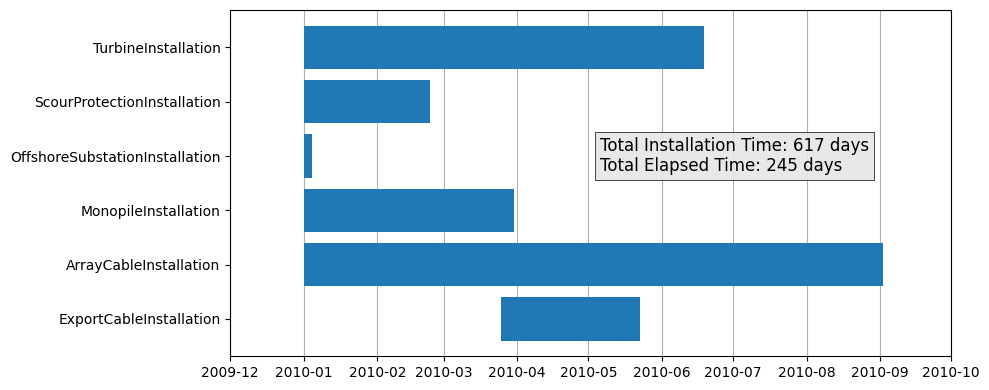

In [25]:
fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)

ax.barh(y=df.index, width=df.end - df.start, left=df.start);

annotation = (
    f"Total Installation Time: {project.installation_time / 24:.0f} days\n"
    f"Total Elapsed Time: {project.project_days} days"
)
ax.text(
    pd.to_datetime("2010-05-06"), 3, annotation,
    bbox={"boxstyle": "square", "fc": (0.9, 0.9, 0.9, 0.9), "linewidth": 0.5},
    ha="left", va="center", size=12,
)

ax.grid(axis="x")
ax.set_axisbelow(True)
ax.set_xlim(pd.to_datetime("2009-12"), pd.to_datetime("2010-10"))
fig.tight_layout()

### Detailed Event Timing

The `actions` property provides access to a JSON-style list of every step taken during the
installation simulation. It is highly recommended to convert this to a Pandas DataFrame or similar
for inspection. Below, we will walk through some basic filtering of these data.

In [26]:
df = pd.DataFrame(project.actions)
df.head()

,cost_multiplier,agent,action,duration,cost,level,time,phase,phase_name,site_depth,hub_height,per_trip,location,max_waveheight,max_windspeed,transit_speed
0,0,Array Cable Installation Vessel,Mobilize,72,"361,756",ACTION,0,ArrayCableInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,WTIV,Mobilize,168,"2,800,000",ACTION,0,MonopileInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,Heavy Lift Vessel,Mobilize,72,"936,918",ACTION,0,OffshoreSubstationInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,Feeder 0,Mobilize,72,"220,858",ACTION,0,OffshoreSubstationInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,SPI Vessel,Mobilize,72,"224,860",ACTION,0,ScourProtectionInstallation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Using the data frame we can filter produce vessel timing summaries for a single phase or a single
vessel, or any combination of vessels and phases. Below is a demonstration of filtering the time
spent in various activities during the monopile installation. From an operational standpoint, this
provides insight into what actions take the longest or cost the most, and can provide a means to
identify room for innovation or process efficiencies. Please see the
[project manager phase timing tutorial](#phase-dependent-timing) for more information about
customizing timing dependencies.

In [27]:
mp_install = df.loc[df.phase.eq("MonopileInstallation")]
mp_vessel_summary = (
    mp_install[["agent", "action", "duration", "cost"]]
    .groupby(["agent", "action"])
    .sum()
)
mp_vessel_summary

duration       cost
agent action                                       
WTIV  Bolt TP                        200  3,333,333
      Crane Reequip                  100  1,666,667
      Drive Monopile                  75  1,250,000
      Fasten Monopile                600 10,000,000
      Fasten Transition Piece        400  6,666,667
      Jackdown                        16    263,889
      Jackup                          16    263,889
      Lower Monopile                   0      2,708
      Lower TP                        50    833,333
      Mobilize                       168  2,800,000
      Position Onsite                100  1,666,667
      Release Monopile               150  2,500,000
      Release Transition Piece       100  1,666,667
      RovSurvey                       50    833,333
      Transit                        236  3,926,667
      Upend Monopile                  30    507,731

## Cash Flow and Net Present Value

The `ProjectManager` includes a basic cash flow and net present value (NPV) model. The project must
have the array, export, and substation installation models configured for this model to be
applicable. The model will find the point in the project logs where the substation and export
cable installations were completed and where each completed string of array cables and turbines
was installed. When all three of these conditions are met, the project can begin to generate energy
and produce revenue. The revenue generation is then superimposed on the monthly spend of the
installation models for the `project.cash_flow`. Please note this assumes a fixed operational
expenditure (OpEx).

The NPV of the project can then be calculated and is available through `npv`. The underlying
financial assumptions for this model are also contained within the `project_parameters` section of
the ORBIT configuration.

In [28]:
print(f"NPV: ${project.npv / 1e6:,.2f} (millions, USD)")

NPV: $1,493.98 (millions, USD)


Below, we highlight the first 12 months of the project cash flow. In the 10th month we can see that
there are no more installation costs, and the project produces the same values for each field
until the end of the project.

In [29]:
pd.concat(
    [
        pd.DataFrame(project.monthly_opex.values(), columns=["monthly_opex"]),
        pd.DataFrame(project.monthly_expenses.values(), columns=["monthly_expenses"]),
        pd.DataFrame(project.monthly_revenue.values(), columns=["monthly_revenue"]),
        pd.DataFrame(project.cash_flow.values(), columns=["cash_flow"]),
    ],
    axis=1
).head(12)

,monthly_opex,monthly_expenses,monthly_revenue,cash_flow
0,0,"46,066,982",0,"-46,066,982"
1,0,"35,066,817",0,"-35,066,817"
2,0,"33,022,562",0,"-33,022,562"
3,0,"27,488,874",0,"-27,488,874"
4,"4,500,000","30,140,361","8,409,600","-21,730,761"
5,"6,300,000","19,454,129","11,773,440","-7,680,689"
6,"7,200,000","15,594,619","13,455,360","-2,139,259"
7,"7,500,000","14,520,562","14,016,000","-504,562"
8,"7,500,000","8,078,377","14,016,000","5,937,623"
9,"7,500,000","7,500,000","14,016,000","6,516,000"
